# 1. Goal: Build a system to identify unreliable/fake news


https://www.nltk.org/api/nltk.help.html

Natural Language Processing with Python provides a practical introduction to programming for language processing. Written by the creators of NLTK, it guides the reader through the fundamentals of writing Python programs, working with corpora, categorizing text, analyzing linguistic structure, and more. The online version of the book has been been updated for Python 3 and NLTK 3

#### Dataset used - https://www.kaggle.com/c/fake-news/data

### Dataset Description-USED from KAGGLE SOURCED - REDUCED to load to COLAB

train.csv: A full training dataset with the following attributes:

* id: unique id for a news article
* title: the title of a news article
* author: author of the news article
* text: the text of the article; could be incomplete
* label: a label that marks the article as potentially unreliable
  * 1: unreliable
  * 0: reliable

test.csv: A testing training dataset with all the same attributes at train.csv without the label.

submit.csv: A sample submission that you can use to submit your prediction results

# 2. Import required libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import re
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn import metrics
import itertools


The Natural Language Toolkit (NLTK) is a platform used for building Python programs that work with human language data for applying in statistical natural language processing (NLP). It contains text processing libraries for tokenization, parsing, classification, stemming, tagging and semantic reasoning.

Stopwords are words which occur frequently in a corpus. e.g a, an, the, in. Frequently occurring words are removed from the corpus for the purpose of text-normalization.

In [2]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [3]:
# Printing the stopwords in English
# We will have to remove these from the corpus during our analysis and pre-processing
print(stopwords.words('english'))

['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're", "you've", "you'll", "you'd", 'your', 'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', "she's", 'her', 'hers', 'herself', 'it', "it's", 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves', 'what', 'which', 'who', 'whom', 'this', 'that', "that'll", 'these', 'those', 'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do', 'does', 'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until', 'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into', 'through', 'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once', 'here', 'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more', 'most', 'other', 'some', 'such', 'no', 'nor', 'not', 'only', 'own', 'same', 'so', 'than', '

# 3. Data Pre-processing and Analysis

####SAME steps as Week 19/20/21 Classes and SOLVED samples

## 3.1 Load the dataset, Read and Parse Text

In [4]:
# First let's load the dataset
#open(..., 'r', encoding='utf-8') vs Latin 1 from Stack Overflow
news_dataset = pd.read_csv("train.csv",encoding='latin-1')

In [5]:
news_dataset.head()

,id,title,author,text,label
0,0,House Dem Aide: We Didnât Even See Comeyâs...,Darrell Lucus,House Dem Aide: We Didnât Even See Comeyâs...,1
1,1,"FLYNN: Hillary Clinton, Big Woman on Campus - ...",Daniel J. Flynn,Ever get the feeling your life circles the rou...,0
2,2,Why the Truth Might Get You Fired,Consortiumnews.com,"Why the Truth Might Get You Fired October 29, ...",1
3,3,15 Civilians Killed In Single US Airstrike Hav...,Jessica Purkiss,Videos 15 Civilians Killed In Single US Airstr...,1
4,4,Iranian woman jailed for fictional unpublished...,Howard Portnoy,Print \nAn Iranian woman has been sentenced to...,1


In [6]:
news_dataset.shape

(20800, 5)

In [7]:
# Checking for missing values
news_dataset.isnull().sum()

id           0
title      558
author    1957
text        39
label        0
dtype: int64

In [8]:
# Let's replace the missing values with empty strings wherever possible
news_dataset = news_dataset.fillna('')

In [9]:
news_dataset.isnull().sum()

id        0
title     0
author    0
text      0
label     0
dtype: int64

In [10]:
# We will use all text fields such as Title, Author & text description to train our model 
# to help predict if it is real or unreliable news
news_dataset['text_corpus'] = news_dataset['author']+' '+news_dataset['title']+' '+news_dataset['text']

In [16]:
print(news_dataset['text_corpus'])

0        Darrell Lucus House Dem Aide: We Didnât Even...
1        Daniel J. Flynn FLYNN: Hillary Clinton, Big Wo...
2        Consortiumnews.com Why the Truth Might Get You...
3        Jessica Purkiss 15 Civilians Killed In Single ...
4        Howard Portnoy Iranian woman jailed for fictio...
                               ...                        
25111    Jerome Hudson Rapper T.I.: Trump a âPoster C...
25112    Benjamin Hoffman N.F.L. Playoffs: Schedule, Ma...
25113    Michael J. de la Merced and Rachel Abrams Macy...
25114    Alex Ansary NATO, Russia To Hold Parallel Exer...
25115    David Swanson What Keeps the F-35 Alive   Davi...
Name: text_corpus, Length: 25116, dtype: object


In [11]:
news_dataset.head()

,id,title,author,text,label,text_corpus
0,0,House Dem Aide: We Didnât Even See Comeyâs...,Darrell Lucus,House Dem Aide: We Didnât Even See Comeyâs...,1,Darrell Lucus House Dem Aide: We Didnât Even...
1,1,"FLYNN: Hillary Clinton, Big Woman on Campus - ...",Daniel J. Flynn,Ever get the feeling your life circles the rou...,0,"Daniel J. Flynn FLYNN: Hillary Clinton, Big Wo..."
2,2,Why the Truth Might Get You Fired,Consortiumnews.com,"Why the Truth Might Get You Fired October 29, ...",1,Consortiumnews.com Why the Truth Might Get You...
3,3,15 Civilians Killed In Single US Airstrike Hav...,Jessica Purkiss,Videos 15 Civilians Killed In Single US Airstr...,1,Jessica Purkiss 15 Civilians Killed In Single ...
4,4,Iranian woman jailed for fictional unpublished...,Howard Portnoy,Print \nAn Iranian woman has been sentenced to...,1,Howard Portnoy Iranian woman jailed for fictio...


In [12]:
# Now we will separate the data and label i.e. text_corpus and label fields
X = news_dataset.drop(columns='label', axis=1)
Y = news_dataset['label']

In [13]:
X = news_dataset['text_corpus']
print(X)

0        Darrell Lucus House Dem Aide: We Didnât Even...
1        Daniel J. Flynn FLYNN: Hillary Clinton, Big Wo...
2        Consortiumnews.com Why the Truth Might Get You...
3        Jessica Purkiss 15 Civilians Killed In Single ...
4        Howard Portnoy Iranian woman jailed for fictio...
                               ...                        
20795    Jerome Hudson Rapper T.I.: Trump a âPoster C...
20796    Benjamin Hoffman N.F.L. Playoffs: Schedule, Ma...
20797    Michael J. de la Merced and Rachel Abrams Macy...
20798    Alex Ansary NATO, Russia To Hold Parallel Exer...
20799    David Swanson What Keeps the F-35 Alive   Davi...
Name: text_corpus, Length: 20800, dtype: object


In [14]:
print(Y)

0        1
1        0
2        1
3        1
4        1
        ..
20795    0
20796    0
20797    0
20798    1
20799    1
Name: label, Length: 20800, dtype: int64


In [15]:
X.head()

0    Darrell Lucus House Dem Aide: We Didnât Even...
1    Daniel J. Flynn FLYNN: Hillary Clinton, Big Wo...
2    Consortiumnews.com Why the Truth Might Get You...
3    Jessica Purkiss 15 Civilians Killed In Single ...
4    Howard Portnoy Iranian woman jailed for fictio...
Name: text_corpus, dtype: object

## 3.2 Remove Special Characters 

- Pick all alphabet characters - lowercase and uppercase...all others such as numbers and punctuations will be removed.
- Numbers or punctuations will be replaced by a whitespace

## 3.3 Remove Stopwords

- Remove standard english stopwords

## 3.4 Stemming or Lemmatization

- Here we will try to apply stemming - objective is to reduce the word to it's root word.
- For example: actor, actress, acting, action --> act
In brief, stemming is the process of reducing a word to its word stem. Word stem is a base or root form of the word and doesn't need to be an existing word. For example, the Porter algorithm reduces the words “argue”, “argued”, “argues” and “arguing” to the stem “argu” which isn't an existing word

In [16]:
port_stem = PorterStemmer()

def stemming(content):
    # Pick all alphabet characters - lowercase and uppercase...all others such as numbers and punctuations will be removed. Numbers or punctuations will be replaced by a whitespace
    stemmed_content = re.sub('[^a-zA-Z]',' ',content)
    # Converting all letters to lowercase 
    stemmed_content = stemmed_content.lower()
    # Converting all to a splitted case or a list
    stemmed_content = stemmed_content.split()
    # Applying stemming, so we get the root words wherever possible + remove stopwords as well
    stemmed_content = [port_stem.stem(word) for word in stemmed_content if not word in stopwords.words('english')]
    # Join all the words in final content
    stemmed_content = ' '.join(stemmed_content)
    return stemmed_content

In [17]:
news_dataset['text_corpus'] = news_dataset['text_corpus'].apply(stemming)

In [18]:
print(news_dataset['text_corpus'])

0        darrel lucu hous dem aid even see comey letter...
1        daniel j flynn flynn hillari clinton big woman...
2        consortiumnew com truth might get fire truth m...
3        jessica purkiss civilian kill singl us airstri...
4        howard portnoy iranian woman jail fiction unpu...
                               ...                        
20795    jerom hudson rapper trump poster child white s...
20796    benjamin hoffman n f l playoff schedul matchup...
20797    michael j de la merc rachel abram maci said re...
20798    alex ansari nato russia hold parallel exercis ...
20799    david swanson keep f aliv david swanson author...
Name: text_corpus, Length: 20800, dtype: object


In [19]:
# Separating data and label
X = news_dataset['text_corpus'].values
Y = news_dataset['label'].values

In [20]:
print(X)

['darrel lucu hous dem aid even see comey letter jason chaffetz tweet hous dem aid even see comey letter jason chaffetz tweet darrel lucu octob subscrib jason chaffetz stump american fork utah imag courtesi michael jolley avail creativ common licens apolog keith olbermann doubt worst person world week fbi director jame comey accord hous democrat aid look like also know second worst person well turn comey sent infam letter announc fbi look email may relat hillari clinton email server rank democrat relev committe hear comey found via tweet one republican committe chairmen know comey notifi republican chairmen democrat rank member hous intellig judiciari oversight committe agenc review email recent discov order see contain classifi inform long letter went oversight committe chairman jason chaffetz set polit world ablaz tweet fbi dir inform fbi learn exist email appear pertin investig case reopen jason chaffetz jasoninthehous octob cours know case comey actual say review email light unrel 

In [21]:
print(Y)

[1 0 1 ... 0 1 1]


## 3.5 TF-IDF (Term Frequency, Inverse Document Frequency)

### Converting Textual data to Numerical data

* We will use TF-IDF Vectorizer
* TF-IDF Vectorizer will convert textual data to numerical data
TF-IDF was invented for document search and information retrieval. It works by increasing proportionally to the number of times a word appears in a document, but is offset by the number of documents that contain the word.

In [22]:
vectorizer = TfidfVectorizer()
vectorizer.fit(X)

X = vectorizer.transform(X)

In [23]:
print(X)

  (0, 109752)	0.049158312425168854
  (0, 109697)	0.0190646711515277
  (0, 108742)	0.04416544119908134
  (0, 108738)	0.09477494042884232
  (0, 108695)	0.03758488097939004
  (0, 108658)	0.01130614774071694
  (0, 108007)	0.017092546683505856
  (0, 107190)	0.017105936674103112
  (0, 107099)	0.012543234221230963
  (0, 107013)	0.029126417104928328
  (0, 106934)	0.012863319680563097
  (0, 106734)	0.011771716334271506
  (0, 105884)	0.025727197929110487
  (0, 105848)	0.031296701378124764
  (0, 104837)	0.02153649554212262
  (0, 103422)	0.06544555398259812
  (0, 102736)	0.03314918847150756
  (0, 102485)	0.01639612818098454
  (0, 101717)	0.038071924979380216
  (0, 101077)	0.011082403436475742
  (0, 101067)	0.0432044670628921
  (0, 101014)	0.13602128375819167
  (0, 100866)	0.0713092337063475
  (0, 99577)	0.03944988916619374
  (0, 99009)	0.027120358929731154
  :	:
  (20799, 7470)	0.010635431711878486
  (20799, 7143)	0.02816704434978389
  (20799, 6848)	0.03959171777516513
  (20799, 6810)	0.0253655855

# 4. Modeling & Model Evaluation

### Splitting the data into test and train datasets

In [24]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.33, stratify=Y, random_state=50)

### Training the model (model1 : Logistic Regression)

In [25]:
# Training the model
model1 = LogisticRegression()

model1.fit(X_train, Y_train)

LogisticRegression()

### Model Evaluation

In [26]:
# Accuracy Score on Training Data
X_train_prediction = model1.predict(X_train)
training_data_accuracy = accuracy_score(X_train_prediction, Y_train)

print('Accuracy score on the training data: ',training_data_accuracy)

# Accuracy Score on Test Data
X_test_prediction = model1.predict(X_test)
test_data_accuracy = accuracy_score(X_test_prediction, Y_test)

print('Accuracy score on the test data: ',test_data_accuracy)

Accuracy score on the training data:  0.9781859931113662
Accuracy score on the test data:  0.9548368298368298


In [27]:
# Function to plot confusion Matrix
def plot_confusion_matrix(cm, 
                          classes,
                          normalize=False,
                          title='Confusion Matrix',
                          cmap=plt.cm.Blues):
  plt.imshow(cm, interpolation='nearest', cmap=cmap)
  plt.title(title)
  plt.colorbar()
  tick_marks = np.arange(len(classes))
  plt.xticks(tick_marks, classes, rotation=45)
  plt.yticks(tick_marks, classes)
  
  if normalize:
    cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    print("Normalized confusion matrix")
  else:
      print('Confusion matrix, without normalization')
  thresh = cm.max() / 2.
  for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
      plt.text(j, i, cm[i, j],horizontalalignment="center",color="white" if cm[i, j] > thresh else "black")
  plt.tight_layout()
  plt.ylabel('True label')
  plt.xlabel('Predicted label')

Confusion matrix, without normalization


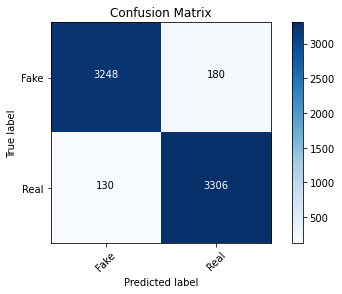

In [28]:
cm = metrics.confusion_matrix(Y_test, X_test_prediction)
plot_confusion_matrix(cm, classes=['Fake', 'Real'])

In [29]:
# Classification report for test data
classification_report(Y_test, X_test_prediction)

'              precision    recall  f1-score   support\n\n           0       0.96      0.95      0.95      3428\n           1       0.95      0.96      0.96      3436\n\n    accuracy                           0.95      6864\n   macro avg       0.95      0.95      0.95      6864\nweighted avg       0.95      0.95      0.95      6864\n'

# 5. Making a Prediction

In [46]:
X_new = X_test[112]

prediction = model1.predict(X_new)
print(prediction)

if (prediction[0] == 0):
  print('According to Johan it is TRUE')
else:
  print('Jono Says this is a Porky')

[1]
Jono Says this is a Porky


In [49]:
news_dataset[100:106]

,id,title,author,text,label,text_corpus
100,100,Technocracy: The Real Reason Why The UN Wants ...,Activist Post,"By Patrick Wood By its very nature, the Intern...",1,activist post technocraci real reason un want ...
101,101,American Drivers Regain Appetite for Gas Guzzl...,Matt Richtel,The single most effective action that most Ame...,0,matt richtel american driver regain appetit ga...
102,102,"Hillary Clinton Builds $150 Million War Chest,...",Nicholas Confessore and Rachel Shorey,Donald J. Trump entered the homestretch of the...,0,nichola confessor rachel shorey hillari clinto...
103,103,Trump Catches What Sick Reporter Snuck In Inte...,Amanda Shea,Trump Catches What Sick Reporter Snuck In Inte...,1,amanda shea trump catch sick report snuck inte...
104,104,All 100 Senators Contacted Russian Government ...,Joel B. Pollak,Attorney General Jeff Sessions found himself a...,0,joel b pollak senat contact russian govern wee...
105,105,10 Images That Perfectly Illustrate the Strugg...,The Anti-Media,\nBy Nick Bernabe\nThe struggle to stop the Da...,1,anti media imag perfectli illustr struggl dako...


In [50]:
print(Y_test[105])

0
